In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import time
import gc
from scipy.stats import zscore
from scipy.ndimage import gaussian_filter1d
import mne
from mne_connectivity import spectral_connectivity_epochs
#truncate mne print
mne.set_log_level('WARNING')
import scienceplots
plt.style.use(['science', 'no-latex'])


In [ ]:
def smooth_with_gaussian(data, sigma=3):
    return gaussian_filter1d(data, sigma=sigma, axis=1) 

def preprocess(data):
    stds = np.std(data[:, :], axis=0)
    non_constant_cols = stds.astype(float) > 1e-6    #finds the time points where std is not 0
    const_cols = stds.astype(float) <= 1e-6    #finds the time points where std is 0

    z = np.zeros_like(data[:, :])   #creates an array of zeros with the same shape as the data
    z[:, non_constant_cols] = zscore(data[:, non_constant_cols], axis=0)  #in the columns where std is not 0, zscores the data
    z[:, const_cols] = np.mean(data[:, const_cols], axis=0)

 
    if np.isnan(z).any():
        raise ValueError("Data contains NaN values after normalization.")

    return z


file_numbers = [1, 2, 4, 8, 14, 15, 20, 23]
def load_data():
    l_al = []
    r_al = []
    l_ar = []
    r_ar = []
    a_al =[]
    a_ar = []
    for file_number in  file_numbers:
        file_total = time.time()
        file_path = f'C:/Users/joshu/PartIIIProject/RSNNdale_attention_{file_number}_attention_test'
        load_data_start_time = time.time()
        data = pickle.load(open(file_path, 'rb'))
        elapsed_time = time.time() - load_data_start_time
        print(f"Dataset {file_number} loaded in {elapsed_time:.2f} seconds")

        attention_labels = data['label_attend'][0]
        label_left = data['label_left'][0]
        label_right = data['label_right'][0]
        attend_01 = data['attend'][0]
        trial_correct = data['trial_correct'][0]
        omitted = data['omit'][0]
        relevant = np.where((omitted == 0) & (trial_correct == 1))[0]

        left = data['SP'][0][0][relevant, 100:350, :]
        right = data['SP'][0][1][relevant, 100:350, :]
        att = data['SP'][0][2][relevant, 100:350, :]

        num_trials, num_samples, num_neurons = left.shape
        num_neurons_attention = 80

        for j in range(0, num_trials):
            for i in range(0, num_neurons):
                count_left = np.count_nonzero(left[j, :, i] == 1)
                if count_left > 0:
                    left[j, :, i] /= count_left
                count_right = np.count_nonzero(right[j, :, i] == 1)
                if count_right > 0:
                    right[j, :, i] /= count_right

            for i in range(0, num_neurons_attention):
                count_attention = np.count_nonzero(att[j, :, i] == 1)
                if count_attention > 0:
                    att[j, :, i] /= count_attention

        left = np.sum(left, axis=2)  # Return a single time series for the output
        right = np.sum(right, axis=2)  # Return a single time series for the output
        att = np.sum(att, axis=2)  # Return a single time series for the output

        left = preprocess(left)
        right = preprocess(right)
        att = preprocess(att) 
    
        # Can now split into left and right attentional modality
        left_indices_agg = np.where((omitted == 0) & (attend_01 == 0) & (label_left != label_right))[0]  # Indices of agg where left
        _, left_indices, _ = np.intersect1d(relevant, left_indices_agg, return_indices = True)   # Indices for relevant processed data where attention left
        right_indices_agg = np.where((omitted == 0) & (attend_01 == 1) & (label_left != label_right))[0]
        _, right_indices, _ = np.intersect1d(relevant, right_indices_agg, return_indices = True)


        # Splitting left and right
        l_al.append(smooth_with_gaussian(left[left_indices], sigma = 2))  # Axis 1 will smooth all of these across time
        r_al.append(smooth_with_gaussian(right[left_indices], sigma = 2))
        a_al.append(smooth_with_gaussian(att[left_indices], sigma = 2))

        l_ar.append(smooth_with_gaussian(left[right_indices], sigma = 2))
        r_ar.append(smooth_with_gaussian(right[right_indices], sigma = 2))
        a_ar.append(smooth_with_gaussian(att[right_indices], sigma = 2))
        

        del left, right, att, data
        gc.collect()
        file_time = time.time() - load_data_start_time
        print(f'Dataset {file_number} complete in {file_time:.2f} seconds')

    return l_al, r_al, l_ar, r_ar, a_al, a_ar



In [ ]:
l_al, r_al, l_ar, r_ar, a_al, a_ar = load_data()

Dataset 1 loaded in 8.72 seconds
Dataset 1 complete in 11.686850547790527
Dataset 2 loaded in 6.31 seconds
Dataset 2 complete in 8.292191982269287
Dataset 4 loaded in 5.43 seconds
Dataset 4 complete in 6.995965480804443
Dataset 8 loaded in 7.11 seconds
Dataset 8 complete in 9.322289943695068
Dataset 14 loaded in 5.87 seconds
Dataset 14 complete in 7.84699821472168
Dataset 15 loaded in 5.50 seconds
Dataset 15 complete in 7.325185775756836
Dataset 20 loaded in 5.68 seconds
Dataset 20 complete in 7.434694528579712
Dataset 23 loaded in 5.84 seconds
Dataset 23 complete in 8.826037168502808


In [ ]:
bands = ['delta', 'theta', 'alpha', 'beta', 'gamma']
sfreq = 500.0
ch_names = ['left_input', 'right_input', 'attention_layer']
ch_types = ['eeg', 'eeg', 'eeg']

freq_ranges = [(0, 4), (4, 8), (8, 13), (13, 30), (30, 80)]

# Initialize granger_results as a nested dictionary for each file, condition, and band


def granger_calc(left, right, attention):
    results = []
    freqs = []
    for idx, fn in enumerate(file_numbers):
        info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types=ch_types)

        data= np.stack([
            left[idx], 
            right[idx], 
            attention[idx]
        ], axis=1) 
        print(data.shape)

        epochs = mne.EpochsArray(
            data,
            info, 
            tmin=0, 
            baseline=None
        )

            # Define channel indices for Granger causality
        seeds = np.array([[0], [1]])
        targets = np.array([[2], [2]])
        indices = (seeds, targets)

        # Compute Granger causality
        gc = spectral_connectivity_epochs(
            epochs, method='gc', indices=indices, sfreq=sfreq,
            fmin=0.5, fmax=40.0, tmin=0.0, tmax=(250 - 1) / sfreq, gc_n_lags=5
        )

      
        # Extract Granger causality data
        gc_data = gc.get_data()
        freqs = gc.freqs

        results.append(gc_data)
        freqs = gc.freqs

    return results, freqs


In [ ]:
left_results, freqs = granger_calc(l_al, r_al, a_al)
right_results, freqs = granger_calc(l_ar, r_ar, a_ar)

(328, 3, 250)


C:\Users\joshu\AppData\Local\Temp\ipykernel_17452\907049264.py:37: RuntimeWarning: There were no Annotations stored in <EpochsArray | 328 events (all good), 0 – 0.498 s (baseline off), ~1.9 MiB, data loaded,
 '1': 328>, so metadata was not modified.
  gc = spectral_connectivity_epochs(
C:\Users\joshu\AppData\Local\Temp\ipykernel_17452\907049264.py:37: RuntimeWarning: fmin=0.500 Hz corresponds to 0.250 < 5 cycles based on the epoch length 0.500 sec, need at least 10.000 sec epochs or fmin=10.000. Spectrum estimate will be unreliable.
  gc = spectral_connectivity_epochs(


(333, 3, 250)
(305, 3, 250)


C:\Users\joshu\AppData\Local\Temp\ipykernel_17452\907049264.py:37: RuntimeWarning: There were no Annotations stored in <EpochsArray | 333 events (all good), 0 – 0.498 s (baseline off), ~1.9 MiB, data loaded,
 '1': 333>, so metadata was not modified.
  gc = spectral_connectivity_epochs(
C:\Users\joshu\AppData\Local\Temp\ipykernel_17452\907049264.py:37: RuntimeWarning: fmin=0.500 Hz corresponds to 0.250 < 5 cycles based on the epoch length 0.500 sec, need at least 10.000 sec epochs or fmin=10.000. Spectrum estimate will be unreliable.
  gc = spectral_connectivity_epochs(
C:\Users\joshu\AppData\Local\Temp\ipykernel_17452\907049264.py:37: RuntimeWarning: There were no Annotations stored in <EpochsArray | 305 events (all good), 0 – 0.498 s (baseline off), ~1.8 MiB, data loaded,
 '1': 305>, so metadata was not modified.
  gc = spectral_connectivity_epochs(
C:\Users\joshu\AppData\Local\Temp\ipykernel_17452\907049264.py:37: RuntimeWarning: fmin=0.500 Hz corresponds to 0.250 < 5 cycles based on

(339, 3, 250)
(335, 3, 250)


...

C:\Users\joshu\AppData\Local\Temp\ipykernel_17452\907049264.py:37: RuntimeWarning: There were no Annotations stored in <EpochsArray | 359 events (all good), 0 – 0.498 s (baseline off), ~2.1 MiB, data loaded,
 '1': 359>, so metadata was not modified.
  gc = spectral_connectivity_epochs(
C:\Users\joshu\AppData\Local\Temp\ipykernel_17452\907049264.py:37: RuntimeWarning: fmin=0.500 Hz corresponds to 0.250 < 5 cycles based on the epoch length 0.500 sec, need at least 10.000 sec epochs or fmin=10.000. Spectrum estimate will be unreliable.
  gc = spectral_connectivity_epochs(
C:\Users\joshu\AppData\Local\Temp\ipykernel_17452\907049264.py:37: RuntimeWarning: There were no Annotations stored in <EpochsArray | 237 events (all good), 0 – 0.498 s (baseline off), ~1.4 MiB, data loaded,
 '1': 237>, so metadata was not modified.
  gc = spectral_connectivity_epochs(
C:\Users\joshu\AppData\Local\Temp\ipykernel_17452\907049264.py:37: RuntimeWarning: fmin=0.500 Hz corresponds to 0.250 < 5 cycles based on

(352, 3, 250)
(366, 3, 250)
(350, 3, 250)


C:\Users\joshu\AppData\Local\Temp\ipykernel_17452\907049264.py:37: RuntimeWarning: There were no Annotations stored in <EpochsArray | 352 events (all good), 0 – 0.498 s (baseline off), ~2.0 MiB, data loaded,
 '1': 352>, so metadata was not modified.
  gc = spectral_connectivity_epochs(
C:\Users\joshu\AppData\Local\Temp\ipykernel_17452\907049264.py:37: RuntimeWarning: fmin=0.500 Hz corresponds to 0.250 < 5 cycles based on the epoch length 0.500 sec, need at least 10.000 sec epochs or fmin=10.000. Spectrum estimate will be unreliable.
  gc = spectral_connectivity_epochs(
C:\Users\joshu\AppData\Local\Temp\ipykernel_17452\907049264.py:37: RuntimeWarning: There were no Annotations stored in <EpochsArray | 366 events (all good), 0 – 0.498 s (baseline off), ~2.1 MiB, data loaded,
 '1': 366>, so metadata was not modified.
  gc = spectral_connectivity_epochs(
C:\Users\joshu\AppData\Local\Temp\ipykernel_17452\907049264.py:37: RuntimeWarning: fmin=0.500 Hz corresponds to 0.250 < 5 cycles based on

(339, 3, 250)


C:\Users\joshu\AppData\Local\Temp\ipykernel_17452\907049264.py:37: RuntimeWarning: There were no Annotations stored in <EpochsArray | 339 events (all good), 0 – 0.498 s (baseline off), ~1.9 MiB, data loaded,
 '1': 339>, so metadata was not modified.
  gc = spectral_connectivity_epochs(
C:\Users\joshu\AppData\Local\Temp\ipykernel_17452\907049264.py:37: RuntimeWarning: fmin=0.500 Hz corresponds to 0.250 < 5 cycles based on the epoch length 0.500 sec, need at least 10.000 sec epochs or fmin=10.000. Spectrum estimate will be unreliable.
  gc = spectral_connectivity_epochs(


In [ ]:
def plot_granger(data):
    for ds_idx, gc_arr in enumerate(data):
        plt.figure(figsize=(10, 5))
        plt.plot(freqs, gc_arr[0, :], label='Left → Attention')
        plt.plot(freqs, gc_arr[1, :], label='Right → Attention')
        plt.title(f'Granger Causality vs Frequency (Dataset {file_numbers[ds_idx]})')
        plt.xlabel('Frequency (Hz)')
        plt.ylabel('Granger Causality')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()



In [ ]:
# Compute average Granger causality for each band, for each dataset, for each condition
# Output arrays: shape (n_datasets, n_bands)

def compute_band_averages(results, freqs, bands, freq_ranges):
    n_datasets = len(results)
    n_bands = len(bands)
    freqs_arr = np.array(freqs)  # Ensure freqs is a NumPy array
    left_to_att = np.zeros((n_datasets, n_bands))
    right_to_att = np.zeros((n_datasets, n_bands))
    for idx, gc in enumerate(results):
        for band_idx, (fmin, fmax) in enumerate(freq_ranges):
            band_mask = (freqs_arr >= fmin) & (freqs_arr < fmax)
            left_to_att[idx, band_idx] = np.mean(gc[0, band_mask])
            right_to_att[idx, band_idx] = np.mean(gc[1, band_mask])
    return left_to_att, right_to_att

# For attend-left (l_al, r_al)
lal_band_avg, ral_band_avg = compute_band_averages(left_results, freqs, bands, freq_ranges)
# For attend-right (l_ar, r_ar)
lar_band_avg, rar_band_avg = compute_band_averages(right_results, freqs, bands, freq_ranges)

g_in = (lal_band_avg + rar_band_avg) / 2
g_out = (lar_band_avg + ral_band_avg) / 2
              

C:\Users\joshu\AppData\Local\Temp\ipykernel_17452\3159064160.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(np.arange(-0.5, 3, 0.5), fontsize=20)


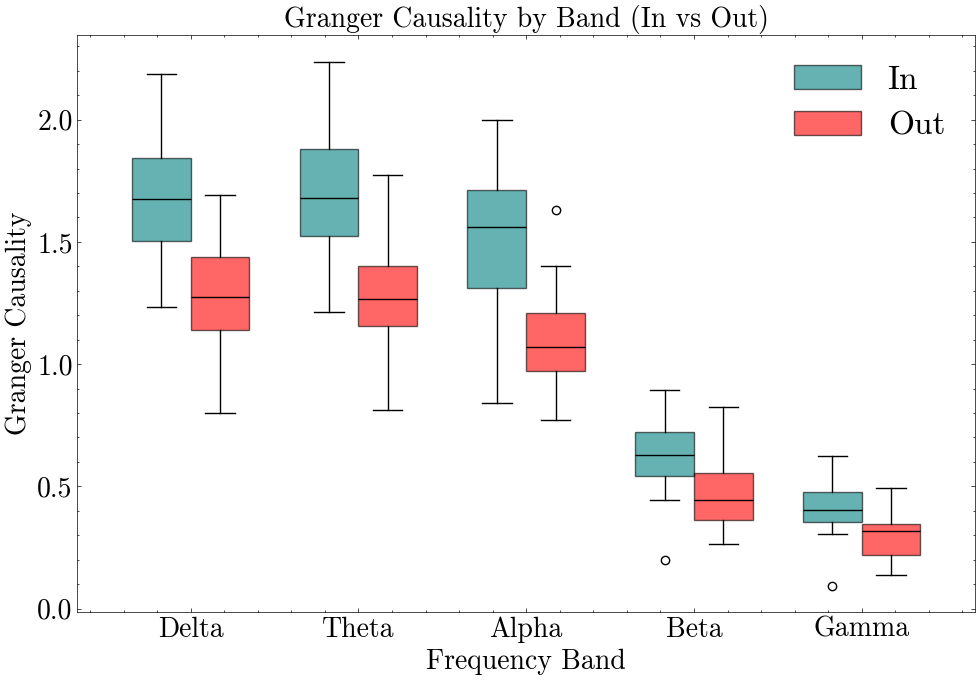

In [ ]:
bands = ['Delta', 'Theta', 'Alpha', 'Beta', 'Gamma']
def plot_Granger_bands(g_in, g_out, bands=None, width=0.35):
    if bands is None:
        n_bands = g_in.shape[1]
        bands = [f'Band {i+1}' for i in range(n_bands)]
    else:
        n_bands = len(bands)

    x = np.arange(n_bands)

    fig, ax = plt.subplots(figsize=(10, 7))

    # Boxplots: In at x-width/2, Out at x+width/2
    bp_in = ax.boxplot([g_in[:, i] for i in range(n_bands)],
                       positions=x - width/2,
                       widths=width,
                       patch_artist=True,
                       boxprops=dict(facecolor='teal', alpha=0.6),
                       medianprops=dict(color='k'))
    bp_out = ax.boxplot([g_out[:, i] for i in range(n_bands)],
                        positions=x + width/2,
                        widths=width,
                        patch_artist=True,
                        boxprops=dict(facecolor='red', alpha=0.6),
                        medianprops=dict(color='k'))

    ax.set_xticks(x)
    ax.set_xticklabels(bands, fontsize=20)
    ax.set_xlabel('Frequency Band', fontsize=20)
    ax.set_yticklabels(np.arange(-0.5, 3, 0.5), fontsize=20)
    ax.set_ylabel('Granger Causality', fontsize=20)
    ax.set_title('Granger Causality by Band (In vs Out)', fontsize=20, fontweight='bold')

    # Legend
    handles = [bp_in['boxes'][0], bp_out['boxes'][0]]
    ax.legend(handles, ['In', 'Out'], loc='upper right', fontsize=24)

    plt.tight_layout()
    plt.show()

plot_Granger_bands(g_in, g_out, bands = bands)

In [ ]:
#ttest on each band
from scipy.stats import ttest_rel
def paired_ttest(g_in, g_out):
    t_stats = []
    p_values = []
    for i in range(g_in.shape[1]):
        t_stat, p_val = ttest_rel(g_in[:, i], g_out[:, i])
        t_stats.append(t_stat)
        p_values.append(p_val)
    return np.array(t_stats), np.array(p_values)

t_stats, p_values = paired_ttest(g_in, g_out)

# Print t-statistics and p-values
for i, band in enumerate(bands):
    print(f"{band}: t-statistic = {t_stats[i]:.3f}, p-value = {p_values[i]}")

delta: t-statistic = 3.311, p-value = 0.012920829010197088
theta: t-statistic = 3.459, p-value = 0.01056186349128894
alpha: t-statistic = 2.980, p-value = 0.020507989339717602
beta: t-statistic = 2.115, p-value = 0.07222771862985328
gamma: t-statistic = 2.084, p-value = 0.0755845847138362


In [ ]:
# Seaborn-only raincloud-style plot for each band and condition (no ptitprince required)
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Prepare data (already in df)
plt.figure(figsize=(12, 7))
sns.set(style="whitegrid", font_scale=1.5)

# Violin plot (the 'cloud')
sns.violinplot(
    x="Band", y="Value", hue="Condition", data=df,
    split=True, inner=None, palette={"In": "teal", "Out": "red"}, cut=0, linewidth=0
)

# Boxplot (the 'box')
sns.boxplot(
    x="Band", y="Value", hue="Condition", data=df,
    showcaps=False, boxprops={'facecolor':'none'}, showfliers=False,
    whiskerprops={'linewidth':0}, palette={"In": "teal", "Out": "red"}
)

# Stripplot (the 'rain')
sns.stripplot(
    x="Band", y="Value", hue="Condition", data=df,
    dodge=True, jitter=True, color="k", alpha=0.4, size=4
)

plt.xlabel('Frequency Band', fontsize=18)
plt.ylabel('Granger Causality', fontsize=18)
plt.title('Raincloud-Style Plot of Granger Causality by Band (All Datapoints)', fontsize=20, fontweight='bold')
plt.legend([],[], frameon=False)  # Remove duplicate legends
plt.tight_layout()
plt.show()


AttributeError: module 'matplotlib' has no attribute 'backends'

In [ ]:
import os
if "MPLBACKEND" in os.environ:
    print("Removing MPLBACKEND:", os.environ["MPLBACKEND"])
    del os.environ["MPLBACKEND"]
else:
    print("MPLBACKEND not set")


Removing MPLBACKEND: module://matplotlib_inline.backend_inline


In [ ]:
import os
# Print and clear MPLBACKEND if set
print('MPLBACKEND before:', os.environ.get('MPLBACKEND'))
os.environ.pop('MPLBACKEND', None)
print('MPLBACKEND after:', os.environ.get('MPLBACKEND'))

import matplotlib
# Try to set a safe backend
try:
    matplotlib.use('agg')  # 'agg' is always available (non-interactive)
    print('matplotlib backend set to:', matplotlib.get_backend())
except Exception as e:
    print('Error setting backend:', e)

# List available interactive backends
print('Available interactive backends:')
print([b for b in matplotlib.rcsetup.interactive_bk])

# Now try importing pyplot
try:
    import matplotlib.pyplot as plt
    print('pyplot imported successfully')
except Exception as e:
    print('Error importing pyplot:', e)


MPLBACKEND before: None
MPLBACKEND after: None
matplotlib backend set to: agg
Available interactive backends:
['gtk3agg', 'gtk3cairo', 'gtk4agg', 'gtk4cairo', 'macosx', 'nbagg', 'notebook', 'qtagg', 'qtcairo', 'qt5agg', 'qt5cairo', 'tkagg', 'tkcairo', 'webagg', 'wx', 'wxagg', 'wxcairo']


C:\Users\joshu\AppData\Local\Temp\ipykernel_6964\2424840120.py:17: MatplotlibDeprecationWarning: The interactive_bk attribute was deprecated in Matplotlib 3.9 and will be removed in 3.11. Use ``matplotlib.backends.backend_registry.list_builtin(matplotlib.backends.BackendFilter.INTERACTIVE)`` instead.
  print([b for b in matplotlib.rcsetup.interactive_bk])


pyplot imported successfully
